In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


Dataset Shape: (15420, 33)


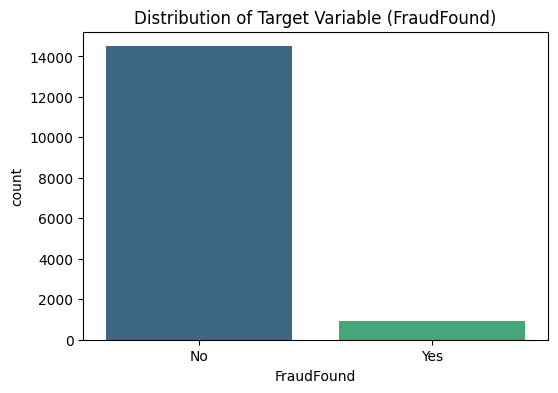

Target Variable Percentage:
FraudFound
No     94.014267
Yes     5.985733
Name: proportion, dtype: float64


In [2]:
df = pd.read_csv('carclaims.csv')

print(f"Dataset Shape: {df.shape}")

# Visualizing the target variable imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='FraudFound', data=df, palette='viridis')
plt.title('Distribution of Target Variable (FraudFound)')
plt.show()

# Display value counts percentage
print("Target Variable Percentage:")
print(df['FraudFound'].value_counts(normalize=True) * 100)

In [3]:
# 3. Data Cleaning
df_clean = df.copy()

# Rename target to match task description and encode as 1 and 0
df_clean = df_clean.rename(columns={'FraudFound': 'FraudFound_P'})
df_clean['FraudFound_P'] = df_clean['FraudFound_P'].map({'Yes': 1, 'No': 0})

# Drop unnecessary columns (PolicyNumber is unique for everyone, acts like ID)
df_clean = df_clean.drop(['PolicyNumber', 'RepNumber'], axis=1)

# We will replace 0 with the median age of the dataset
median_age = df_clean[df_clean['Age'] > 0]['Age'].median()
df_clean.loc[df_clean['Age'] == 0, 'Age'] = median_age

print("Data Cleaning Completed!")

Data Cleaning Completed!


In [4]:
# We use LabelEncoder to convert text columns into numerical values
label_encoders = {}
categorical_columns = df_clean.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    
print("Categorical features encoded successfully.")
df_clean.head()

Categorical features encoded successfully.


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound_P
0,2,5,6,6,1,6,5,1,0,2,...,3,0,0,0,3,0,2,1994,2,0
1,4,3,6,6,1,2,5,4,1,2,...,4,1,0,0,3,3,0,1994,1,0
2,10,5,0,6,1,5,10,2,1,1,...,6,0,0,0,3,3,0,1994,1,0
3,6,2,2,17,0,1,6,1,1,1,...,7,1,0,0,2,3,0,1994,2,0
4,4,5,1,6,1,6,4,2,0,2,...,4,0,0,0,3,3,0,1994,1,0


In [5]:
X = df_clean.drop('FraudFound_P', axis=1)
y = df_clean['FraudFound_P']

# Split the data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE ONLY to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original Training shape: {X_train.shape}")
print(f"Training shape after SMOTE: {X_train_smote.shape}")

Original Training shape: (12336, 30)
Training shape after SMOTE: (23196, 30)


In [6]:
# 6. Model Training & Comparison

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

print("Starting to train 4 different models. Please wait...")

# Model 1: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
rf_pred = rf_model.predict(X_test)
print("- Random Forest: Done!")

# Model 2: Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_smote, y_train_smote)
gb_pred = gb_model.predict(X_test)
print("- Gradient Boosting: Done!")

# Model 3: XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test)
print("- XGBoost: Done!")

# Model 4: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
lr_pred = lr_model.predict(X_test)
print("- Logistic Regression: Done!")

print("\nAll 4 Models Trained Successfully!")

Starting to train 4 different models. Please wait...
- Random Forest: Done!
- Gradient Boosting: Done!
- XGBoost: Done!
- Logistic Regression: Done!

All 4 Models Trained Successfully!


Generating Comparison Plots for all 4 Models...



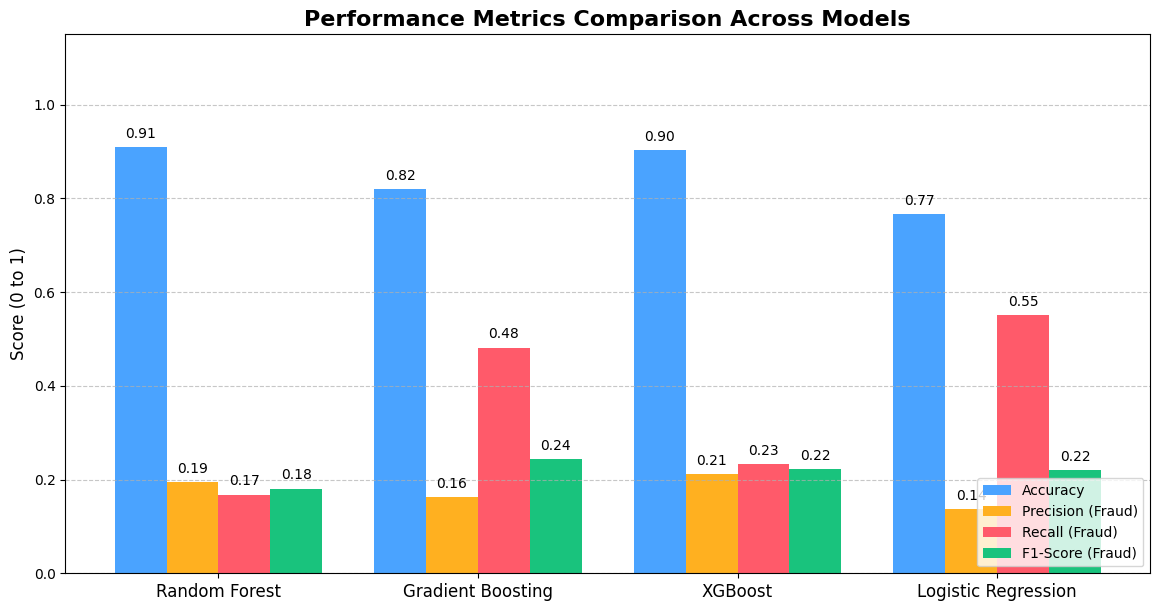

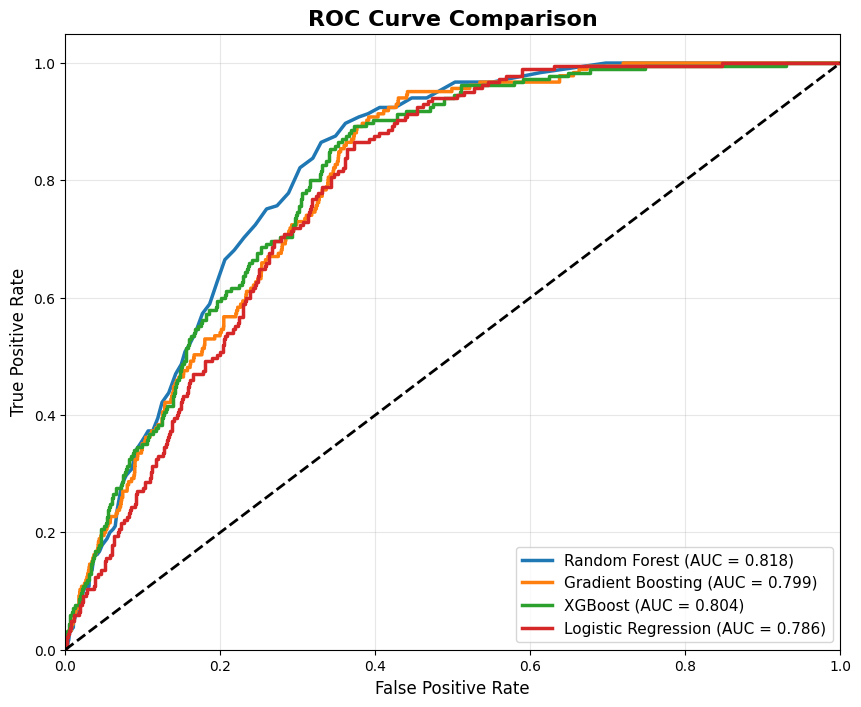

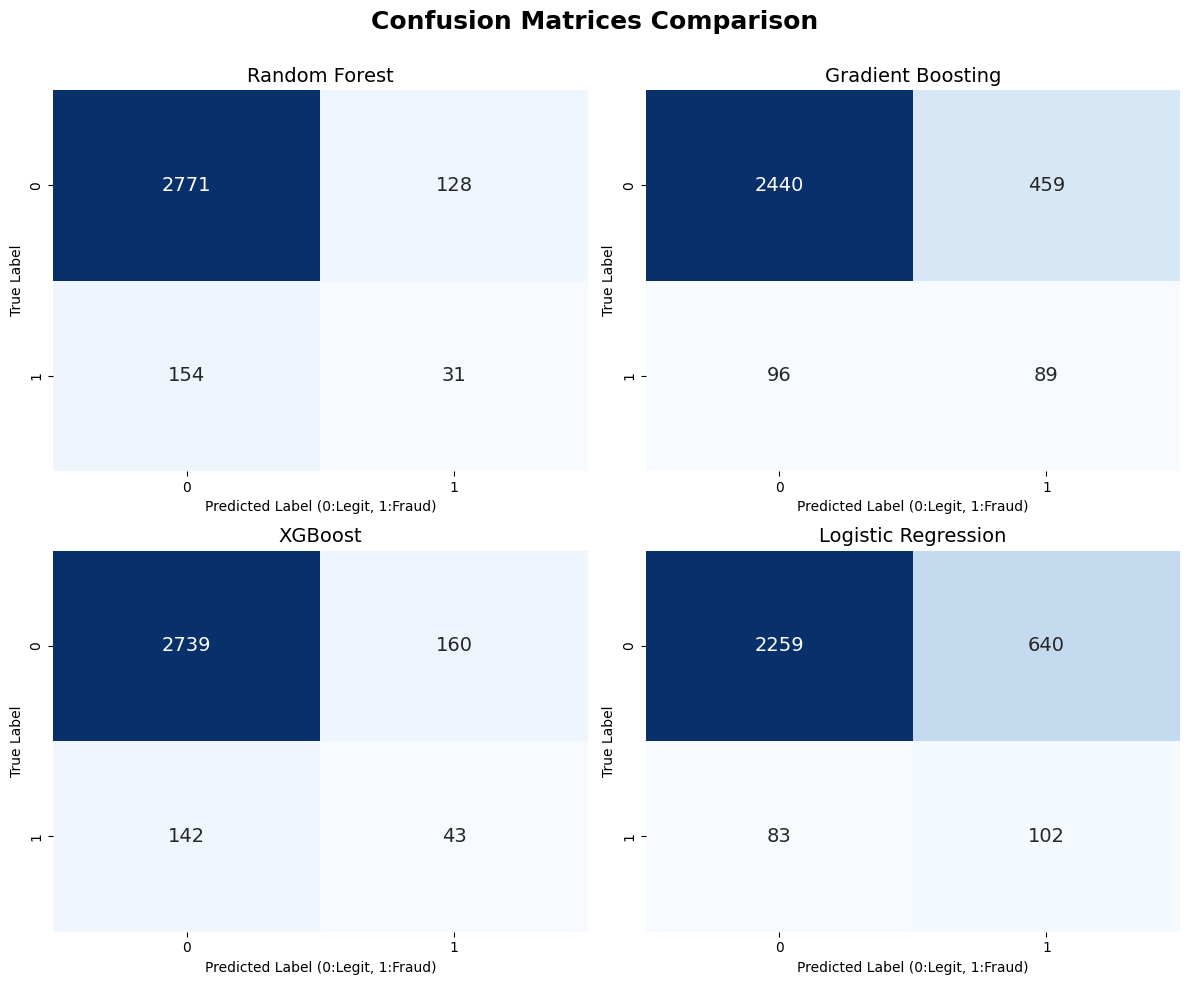

       MODELS PERFORMANCE COMPARISON

1. RANDOM FOREST:
Accuracy: 0.9085603112840467
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2899
           1       0.19      0.17      0.18       185

    accuracy                           0.91      3084
   macro avg       0.57      0.56      0.57      3084
weighted avg       0.90      0.91      0.91      3084


2. GRADIENT BOOSTING:
Accuracy: 0.8200389105058365
              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2899
           1       0.16      0.48      0.24       185

    accuracy                           0.82      3084
   macro avg       0.56      0.66      0.57      3084
weighted avg       0.91      0.82      0.86      3084


3. XGBOOST:
Accuracy: 0.9020752269779507
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2899
           1       0.21      0.23      0.22       185

   

In [9]:
# 7. Model Evaluation & Visual Comparison
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

print("Generating Comparison Plots for all 4 Models...\n")

# 1. Calculate Probabilities for ROC Curve (Probability of Fraud class '1')
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# 2. Gather Predictions & Calculate Metrics
models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Logistic Regression']
predictions = [rf_pred, gb_pred, xgb_pred, lr_pred]
probs = [rf_prob, gb_prob, xgb_prob, lr_prob]

accuracies = [accuracy_score(y_test, p) for p in predictions]
# Using pos_label=1 assuming '1' is the Fraud class
precisions = [precision_score(y_test, p, pos_label=1) for p in predictions]
recalls = [recall_score(y_test, p, pos_label=1) for p in predictions]
f1_scores = [f1_score(y_test, p, pos_label=1) for p in predictions]

# ==========================================
# PLOT 1: Metrics Comparison Bar Chart
# ==========================================
plt.figure(figsize=(14, 7))
x = np.arange(len(models))
width = 0.2

plt.bar(x - 1.5*width, accuracies, width, label='Accuracy', color='#4AA3FF')
plt.bar(x - 0.5*width, precisions, width, label='Precision (Fraud)', color='#FFB020')
plt.bar(x + 0.5*width, recalls, width, label='Recall (Fraud)', color='#FF5A6A')
plt.bar(x + 1.5*width, f1_scores, width, label='F1-Score (Fraud)', color='#19C37D')

plt.ylabel('Score (0 to 1)', fontsize=12)
plt.title('Performance Metrics Comparison Across Models', fontsize=16, fontweight='bold')
plt.xticks(x, models, fontsize=12)
plt.legend(loc='lower right')
plt.ylim(0, 1.15)

# Add text labels on top of bars
for i in range(len(models)):
    plt.text(i - 1.5*width, accuracies[i]+0.02, f'{accuracies[i]:.2f}', ha='center', fontsize=10)
    plt.text(i - 0.5*width, precisions[i]+0.02, f'{precisions[i]:.2f}', ha='center', fontsize=10)
    plt.text(i + 0.5*width, recalls[i]+0.02, f'{recalls[i]:.2f}', ha='center', fontsize=10)
    plt.text(i + 1.5*width, f1_scores[i]+0.02, f'{f1_scores[i]:.2f}', ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# PLOT 2: ROC-AUC Curve Comparison
# ==========================================
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, model_name in enumerate(models):
    fpr, tpr, _ = roc_curve(y_test, probs[i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# PLOT 3: Confusion Matrices Grid
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices Comparison', fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, model_name in enumerate(models):
    cm = confusion_matrix(y_test, predictions[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 14})
    axes[i].set_title(f'{model_name}', fontsize=14)
    axes[i].set_xlabel('Predicted Label (0:Legit, 1:Fraud)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

print("="*40)
print("       MODELS PERFORMANCE COMPARISON")
print("="*40)

print("\n1. RANDOM FOREST:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("\n2. GRADIENT BOOSTING:")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

print("\n3. XGBOOST:")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

print("\n4. LOGISTIC REGRESSION:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Identify the best model based on F1-Score (Fraud)
best_model_idx = np.argmax(f1_scores)
print("="*60)
print(f"🏆 BEST MODEL IDENTIFIED: {models[best_model_idx]}")
print(f"Reason: Highest F1-Score for Fraud Detection ({f1_scores[best_model_idx]:.2f})")
print("="*60)

In [8]:
# We save the model to use it in our FastAPI backend later

model_data = {
    "model": rf_model,
    "encoders": label_encoders, # save encoders to transform API user input later
    "features": list(X.columns)
}

with open("fraud_detection_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Best model saved as 'fraud_detection_model.pkl' successfully!")

Best model saved as 'fraud_detection_model.pkl' successfully!
